In [1]:
from collections.abc import Mapping
from typing import cast

from datasets import Dataset
from datasets import load_dataset as hf_load
from maite_datasets.adapters import from_huggingface

# Download MNIST test split (10 000 images of 28×28 handwritten digits)
mnist_test = cast(Dataset, hf_load("ylecun/mnist", split="test"))

# Convert to MAITE protocol — gives us (image, label, metadata) tuples
mnist_maite = from_huggingface(mnist_test)

print(f"Loaded {len(mnist_maite)} MNIST test images via MAITE adapter")
print(f"Sample shape: image={mnist_maite[0][0].shape}, label={mnist_maite[0][1]}")

/home/aweng/2033/dataeval-flow/.nox/docs/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 10000 MNIST test images via MAITE adapter
Sample shape: image=(1, 28, 28), label=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [2]:
from typing import Any

import numpy as np
from maite_datasets.adapters import HFImageClassificationDataset, HFObjectDetectionDataset
from numpy.typing import NDArray
from PIL import Image, ImageFilter


class DegradedDataset:
    """Wraps a MAITE dataset and applies progressive Gaussian blur to selected classes.

    Parameters
    ----------
    dataset
        A MAITE-compatible dataset returning (image, target, metadata) tuples.
    degraded_classes
        Set of class labels to apply blur to.
    max_blur_radius
        Maximum blur radius applied to the last sample.
    """

    def __init__(
        self,
        dataset: HFImageClassificationDataset | HFObjectDetectionDataset,
        degraded_classes: set[int],
        max_blur_radius: float = 3.0,
    ) -> None:
        self._dataset = dataset
        self._degraded_classes = degraded_classes
        self.max_blur_radius: float = max_blur_radius

    def __len__(self) -> int:
        return len(self._dataset)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, metadata = self._dataset[index]
        t = np.asarray(target)
        label = int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)

        if label in self._degraded_classes:
            # Blur increases linearly with index — simulates progressive degradation
            progress = index / max(len(self) - 1, 1)
            radius = self.max_blur_radius * progress

            if radius > 0.1:  # skip negligible blur
                img_array = np.asarray(image)
                # CHW → HWC if needed
                if img_array.ndim == 3 and img_array.shape[0] in (1, 3):
                    img_array = np.transpose(img_array, (1, 2, 0))

                if img_array.dtype in (np.float32, np.float64):
                    img_pil = Image.fromarray((img_array.squeeze() * 255).astype(np.uint8), mode="L")
                else:
                    img_pil = Image.fromarray(img_array.squeeze(), mode="L")

                img_pil = img_pil.filter(ImageFilter.GaussianBlur(radius=radius))
                blurred = np.array(img_pil, dtype=np.float32) / 255.0
                image = blurred[np.newaxis, :, :]  # back to CHW

        return image, target, metadata

In [3]:

# Wrap the incoming slice with degradation for classes 1, 4, 7
incoming_hf = mnist_test.select(range(2000, 4000))
incoming_maite = from_huggingface(incoming_hf)
incoming_dataset = DegradedDataset(
    incoming_maite,
    degraded_classes={1, 4, 7},
    max_blur_radius=3.0,
)

print(f"Reference: {len(mnist_maite)} total images (will select first 2000)")
print(f"Incoming:  {len(incoming_dataset)} images (classes 1,4,7 progressively blurred)")

Reference: 10000 total images (will select first 2000)
Incoming:  2000 images (classes 1,4,7 progressively blurred)


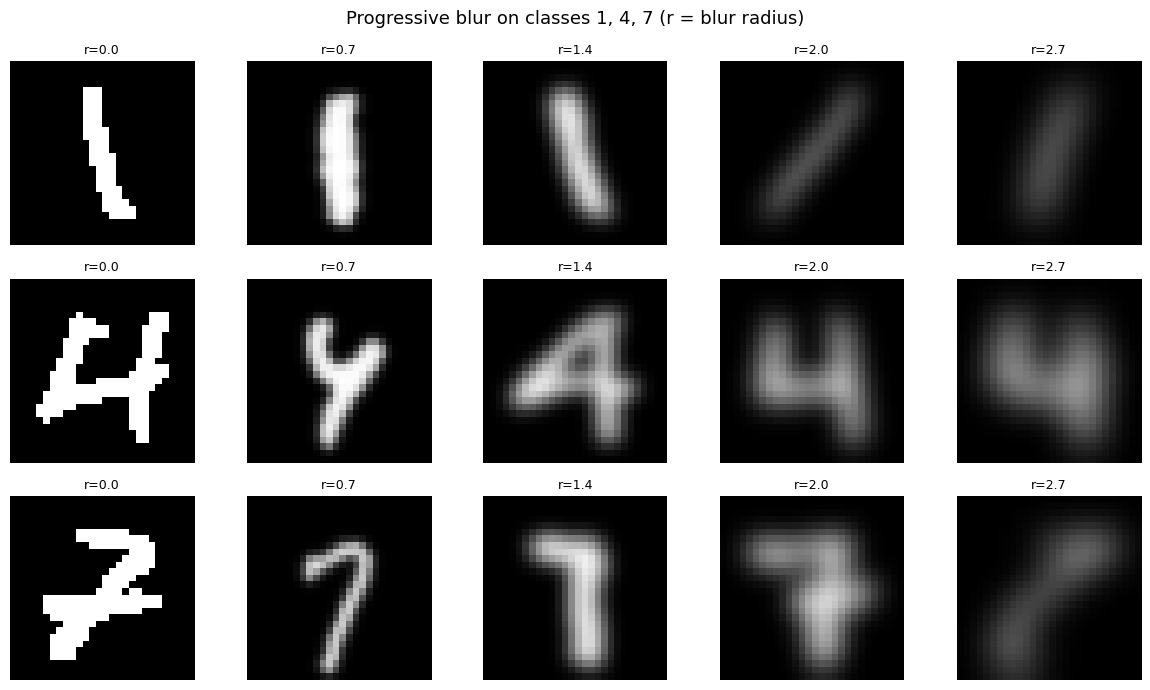

In [4]:
import matplotlib.pyplot as plt

degraded_classes = [1, 4, 7]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(len(degraded_classes), len(positions), figsize=(12, 7))

for row, cls in enumerate(degraded_classes):
    for col, frac in enumerate(positions):
        start = int(frac * len(incoming_dataset) * 0.9)
        for i in range(start, len(incoming_dataset)):
            img, target, _ = incoming_dataset[i]
            t = np.asarray(target)
            label = int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)
            if label == cls:
                img_arr = np.asarray(img).squeeze()
                axes[row, col].imshow(img_arr, cmap="gray", vmin=0, vmax=1)
                radius = incoming_dataset.max_blur_radius * (i / max(len(incoming_dataset) - 1, 1))
                axes[row, col].set_title(f"r={radius:.1f}", fontsize=9)
                break
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"Digit {cls}", fontsize=11, rotation=0, labelpad=40)

fig.suptitle("Progressive blur on classes 1, 4, 7 (r = blur radius)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
from dataeval_flow.config import (
    DatasetProtocolConfig,
    DriftMonitoringTaskConfig,
    DriftMonitoringWorkflowConfig,
    FlattenExtractorConfig,
    PipelineConfig,
    SelectionConfig,
    SelectionStep,
    SourceConfig,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.drift.params import ChunkingConfig, DriftDetectorKNeighbors, DriftHealthThresholds

# --- Datasets (in-memory via DatasetProtocolConfig) ---
ref_config = DatasetProtocolConfig(
    name="reference",
    format="maite",
    dataset=mnist_maite,  # full 10k — selection will subset it
)

incoming_config = DatasetProtocolConfig(
    name="incoming",
    format="maite",
    dataset=incoming_dataset,
)

# --- Selections ---
# Use Indices to select the first 2000 images as the reference baseline
ref_selection = SelectionConfig(
    name="ref-first-2k",
    steps=[SelectionStep(type="Indices", params={"indices": list(range(2000))})],
)

# --- Sources ---
ref_source_config = SourceConfig(name="reference_2k", dataset="reference", selection="ref-first-2k")
inc_source_config = SourceConfig(name="incoming_2k", dataset="incoming")

# --- Extractors ---
extractor_config = FlattenExtractorConfig(
    name="flatten",
    batch_size=64,
)

# --- Workflows ---
drift_workflow_config = DriftMonitoringWorkflowConfig(
    name="overall-drift",
    detectors=[
        DriftDetectorKNeighbors(k=10, chunking=ChunkingConfig(chunk_count=5, threshold_multiplier=1.5)),
    ],
    health_thresholds=DriftHealthThresholds(
        chunk_drift_pct_warning=15.0,
        consecutive_chunks_warning=2,
    ),
)

# --- Phase 1: Overall drift with chunking (no classwise) ---
overall_task = DriftMonitoringTaskConfig(
    name="mnist-overall-drift",
    workflow="overall-drift",
    sources=["reference_2k", "incoming_2k"],
    extractor="flatten",
)

overall_config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    selections=[ref_selection],
    sources=[ref_source_config, inc_source_config],
    extractors=[extractor_config],
    workflows=[drift_workflow_config],
    tasks=[overall_task],
)

In [6]:
from pathlib import Path

overall_result = run_task(overall_task, overall_config, cache_dir=Path("./cache"))

In [7]:
print(overall_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 2000 ITEMS.
  Timestamp:    2026-06-09T17:44:20.325015+00:00
  Duration:     0.22s
  Source:       reference_2k (reference[ref-first-2k])
                incoming_2k (incoming)
  Model:        flatten (flatten)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (chunk_count=5, z=1.5) ..................................   [!!]

  Health: 1 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (CHUNK_COUNT=5, Z=1.5)
  3/5 chunks drifted (60%) | max consecutive: 3

  Chunk         Distance                                  Status
  -----------  ---------  ------------------------------  ------
  [0:399]      1515.8300  █████████████████████████████░  ok
  [400:799]    1525.8806  █████████████████████████████░  ok
  [800:1199]   1506.7025  ████████████████████████████░░  DRIFT
  [1200:1599]  1498.6344  ████████████████████████████░░  DRIFT
  [1600:1999]  1559.4890  █

In [8]:
from dataeval_flow.workflows.drift.params import DriftDetectorMMD, DriftDetectorUnivariate

classwise_task = DriftMonitoringTaskConfig(
    name="mnist-classwise-drift",
    workflow="classwise-drift",
    sources=["reference_2k", "incoming_2k"],
    extractor="flatten",
)

classwise_config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    selections=[ref_selection],
    sources=[ref_source_config, inc_source_config],
    extractors=[extractor_config],
    workflows=[
        DriftMonitoringWorkflowConfig(
            name="classwise-drift",
            detectors=[
                DriftDetectorMMD(n_permutations=100, classwise=True),
                DriftDetectorUnivariate(test="cvm", classwise=True),
            ],
            health_thresholds=DriftHealthThresholds(
                classwise_any_drift_is_warning=True,
            ),
        ),
    ],
    tasks=[classwise_task],
)

In [9]:
classwise_result = run_task(classwise_task, classwise_config, cache_dir=Path("./cache"))

In [10]:
print(classwise_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 2000 ITEMS.
  Timestamp:    2026-06-09T17:44:24.551858+00:00
  Duration:     4.21s
  Source:       reference_2k (reference[ref-first-2k])
                incoming_2k (incoming)
  Model:        flatten (flatten)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  MMD (classwise=True) ............................ 3/10 classes drifted  [!!]
  CVM Univariate (classwise=True) ................. 3/10 classes drifted  [!!]

  Health: 2 warning(s) [!!] — review flagged findings

  MMD (CLASSWISE=TRUE)                                      3/10 classes drifted
  Classes drifted: 1, 4, 7

  Class  Distance    PVal                                  Status
  -----  --------  ------  ------------------------------  ------
  0       -0.0010    0.78  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  ok
  1        0.6948    0.00  ██████████████████████████████  DRIFT
  2        0.0006    0.32  ░░░░░░░░░░░░░░░░░░░

In [11]:
import polars as pl

pl.Config.set_tbl_hide_dataframe_shape(True)

raw = classwise_result.data.raw

# Overall results (from the classwise run)
print("── Overall Drift ──")
for method, det_result in raw.detectors.items():
    status = "DRIFT" if det_result["drifted"] else "ok"
    print(f"  {method}: {status} (distance={det_result['distance']:.4f})")
print()

# Classwise results
if raw.classwise:
    print("── Classwise Drift ──")
    for cw in raw.classwise:
        print(f"\n  Detector: {cw['detector']}")
        rows = [
            {
                "class": r["class_name"],
                "drifted": r["drifted"],
                "distance": round(r["distance"], 4),
                "p_val": round(r["p_val"], 6) if r.get("p_val") is not None else None,  # type:ignore
            }
            for r in cw["rows"]
        ]
        df = pl.DataFrame(rows)
        print(df)

── Overall Drift ──
  mmd: DRIFT (distance=0.0359)
  univariate: DRIFT (distance=2.4165)

── Classwise Drift ──

  Detector: MMD (classwise=True)
┌───────┬─────────┬──────────┬───────┐
│ class ┆ drifted ┆ distance ┆ p_val │
│ ---   ┆ ---     ┆ ---      ┆ ---   │
│ str   ┆ bool    ┆ f64      ┆ f64   │
╞═══════╪═════════╪══════════╪═══════╡
│ 0     ┆ false   ┆ -0.001   ┆ 0.78  │
│ 1     ┆ true    ┆ 0.6948   ┆ 0.0   │
│ 2     ┆ false   ┆ 0.0006   ┆ 0.32  │
│ 3     ┆ false   ┆ -0.0007  ┆ 0.67  │
│ 4     ┆ true    ┆ 0.5741   ┆ 0.0   │
│ 5     ┆ false   ┆ 0.0009   ┆ 0.13  │
│ 6     ┆ false   ┆ -0.0013  ┆ 0.85  │
│ 7     ┆ true    ┆ 0.5831   ┆ 0.0   │
│ 8     ┆ false   ┆ -0.0002  ┆ 0.47  │
│ 9     ┆ false   ┆ 0.0008   ┆ 0.24  │
└───────┴─────────┴──────────┴───────┘

  Detector: CVM Univariate (classwise=True)
┌───────┬─────────┬──────────┬──────────┐
│ class ┆ drifted ┆ distance ┆ p_val    │
│ ---   ┆ ---     ┆ ---      ┆ ---      │
│ str   ┆ bool    ┆ f64      ┆ f64      │
╞═══════╪════════

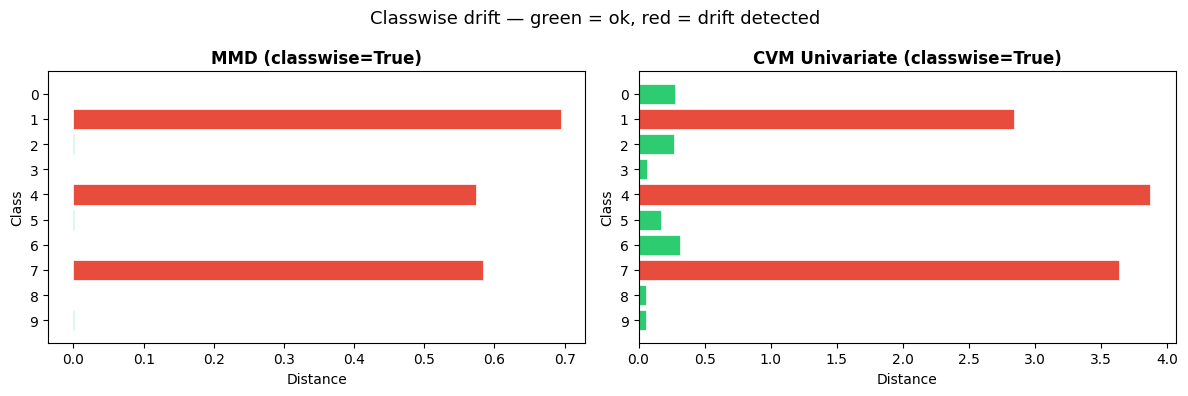

In [12]:
assert raw.classwise is not None  # classwise=True was set on each detector above
detectors = [cw["detector"] for cw in raw.classwise]

fig, axes = plt.subplots(1, len(detectors), figsize=(6 * len(detectors), 4))
if len(detectors) == 1:
    axes = [axes]

for ax, cw in zip(axes, raw.classwise, strict=True):
    class_names = [r["class_name"] for r in cw["rows"]]
    distances = [r["distance"] for r in cw["rows"]]
    drifted = [r["drifted"] for r in cw["rows"]]
    colors = ["#e74c3c" if d else "#2ecc71" for d in drifted]

    ax.barh(class_names, distances, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Class")
    ax.set_title(cw["detector"], fontsize=12, fontweight="bold")
    ax.invert_yaxis()

fig.suptitle("Classwise drift — green = ok, red = drift detected", fontsize=13)
plt.tight_layout()
plt.show()